# Low discrepancy constructions: reading the first points

Author: Fred J. Hickernell

How much of a construction can we recover from its first several points? We investigate **lattice**, **Kronecker**, and **base-two digital** sequences, then compare randomized versions on one fixed Keister integrand. QMCPy supplies the lattice, digital, IID, and integration machinery. A short explicit formula supplies Kronecker points, which have no generator in the course's pinned QMCPy version.

This companion develops [Improving Efficiency: low discrepancy sampling](https://fjhickernell.github.io/MATH565Fall2026/slides/04-improving-efficiency.html#low-discrepancy-sampling). Run with the course `qmcpy` kernel, or use a working copy in Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/sampling/LowDiscrepancyConstructions.ipynb)

In Colab, run setup once, continue in order, and save a copy in Drive to retain changes. Fixed seeds make the figures and comparison reproducible; change them to explore other randomizations.

Samples are indexed $i=0,\ldots,n-1$; coordinates are $j=1,\ldots,d$. Deterministic cube points are $\boldsymbol u_i$, randomized ones $\boldsymbol U_i$.

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

In [2]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import qmcpy as qp
import classlib as cl
from fractions import Fraction
from IPython.display import display, Markdown

%matplotlib inline
cl.nbviz.init(use_tex=True)
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'cm'})


def point_table(points, indices=None, fractions=True):
    """Display a short, zero-indexed table without another table library."""
    if indices is None:
        indices = range(len(points))
    header = '| $i$ | ' + ' | '.join(f'$u_{{i,{j+1}}}$' for j in range(points.shape[1])) + ' |'
    lines = [header, '|---:' + '|---:' * points.shape[1] + '|']
    for i in indices:
        values = [str(Fraction(float(v)).limit_denominator(4096)) if fractions
                  else f'{v:.6f}' for v in points[i]]
        lines.append(f'| {i} | ' + ' | '.join(values) + ' |')
    display(Markdown('\n'.join(lines)))


def radical_inverse_2(indices):
    """Reverse binary digits across the radix point, exposing the formula."""
    indices = np.asarray(indices, dtype=np.uint64).copy()
    values = np.zeros(indices.shape)
    weight = 0.5
    while np.any(indices):
        values += weight * (indices & 1)
        indices >>= 1
        weight *= 0.5
    return values

print(f'QMCPy {qp.__version__}; NumPy {np.__version__}')

QMCPy 2.4; NumPy 2.4.6


## 1. Lattice: recover a generating vector modulo the sample size

For radical-inverse ordering in base two,
\begin{align*}
\phi_2(i)&=i_0/2+i_1/4+i_2/8+\cdots,\\
\boldsymbol u_i&=\phi_2(i)\boldsymbol\zeta\pmod1.
\end{align*}
At $n=2^m$, this is the same **set** as $\{k\boldsymbol\zeta/n\pmod1:0\le k<n\}$, in a different order. Start with the slide generator $\boldsymbol\zeta=(1,3)$ and keep randomization off so the construction is visible. These small teaching generators illustrate arithmetic; use QMCPy's built-in searched generator for the integration comparison.

In [3]:
zeta = np.array([1, 3], dtype=np.uint64)
lattice = qp.Lattice(2, generating_vector=zeta, m_max=10,
                     randomize=False, order='RADICAL INVERSE')
u_lattice = lattice.gen_samples(16, warn=False)
i = np.arange(8)
phi = radical_inverse_2(i)
np.testing.assert_array_equal(u_lattice[:8], (phi[:, None] * zeta) % 1)
point_table(u_lattice, range(8))
display(Markdown('The index digits $000,001,010,011,100,101,110,111$ give '
                 '$\\phi_2(i)=0,1/2,1/4,3/4,1/8,5/8,3/8,7/8$.'))

| $i$ | $u_{i,1}$ | $u_{i,2}$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 1 | 1/2 | 1/2 |
| 2 | 1/4 | 3/4 |
| 3 | 3/4 | 1/4 |
| 4 | 1/8 | 3/8 |
| 5 | 5/8 | 7/8 |
| 6 | 3/8 | 1/8 |
| 7 | 7/8 | 5/8 |

The index digits $000,001,010,011,100,101,110,111$ give $\phi_2(i)=0,1/2,1/4,3/4,1/8,5/8,3/8,7/8$.

### Which point exposes the generator?

In this ordering, $\phi_2(2^{m-1})=1/2^m=1/n$, so
\begin{align*}
n\boldsymbol u_{n/2}=\boldsymbol\zeta\pmod n.
\end{align*}
Thus point $i=4$ reveals $(1,3)$ **modulo 8**. Point $i=1$ only reveals parity; point $i=2$ reveals the generator modulo 4. We can recover residues, not a unique infinite-precision generating vector. Predict the remaining observed points and then test a new point.

In [4]:
n = 8
recovered_zeta = np.rint(n * u_lattice[n // 2]).astype(np.uint64)
print('Recovered generator modulo 8:', recovered_zeta)
predicted = (radical_inverse_2(np.arange(n))[:, None] * recovered_zeta) % 1
np.testing.assert_array_equal(predicted, u_lattice[:n])

# (1,11) has the same residues modulo 8 as (1,3).
alias = qp.Lattice(2, generating_vector=np.array([1, 11], dtype=np.uint64),
                   m_max=10, randomize=False, order='RADICAL INVERSE')
u_alias = alias.gen_samples(16, warn=False)
np.testing.assert_array_equal(u_alias[:8], u_lattice[:8])
assert not np.array_equal(u_alias[8], u_lattice[8])
print('Both generators match the first 8 points.')
print('At i=8: (1,3) gives', u_lattice[8], '; (1,11) gives', u_alias[8])

Recovered generator modulo 8: [1 3]
Both generators match the first 8 points.
At i=8: (1,3) gives [0.0625 0.1875] ; (1,11) gives [0.0625 0.6875]


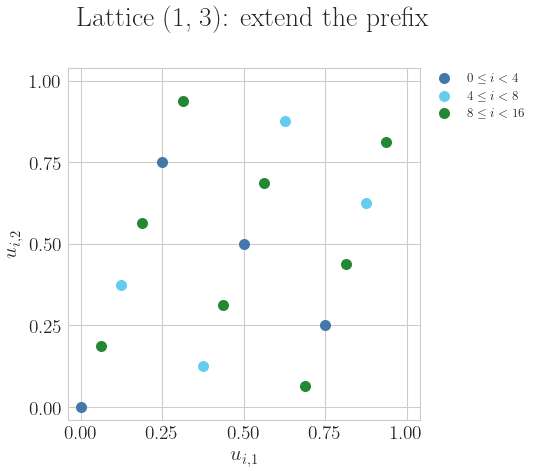

In [5]:
# The origin is intentional in this unrandomized construction demonstration.
# plot_proj does not expose gen_samples(warn=False); filter only that notice.
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='Without randomization, the first lattice point is the origin')
    fig, axes = qp.plot_proj(lattice, n=[4, 8, 16], marker_size=48,
                            figfac=4.5, axis_pad=.04, font_family='serif',
                            fig_title='Lattice (1, 3): extend the prefix')
ax = axes[0, 0]
ax.set_xlabel(r'$u_{i,1}$'); ax.set_ylabel(r'$u_{i,2}$')
ax.legend([r'$0\le i<4$', r'$4\le i<8$', r'$8\le i<16$'],
          fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.set_size_inches(6.8, 4.8)
fig.tight_layout()
plt.show()

The colors show newly added blocks: first 4, next 4, next 8. Earlier points stay fixed. Small sample sizes alone do not establish good projections or integration accuracy for a generator.

## 2. Kronecker: recover a constant torus increment

A Kronecker sequence uses the **ordinary index**, rather than its reversed digits:
\begin{align*}
\boldsymbol u_i=i\boldsymbol\zeta\pmod1,\qquad
(\boldsymbol u_{i+1}-\boldsymbol u_i)\pmod1=\boldsymbol\zeta\pmod1.
\end{align*}
With no shift, point $i=1$ gives the increment. With an ordinary shift, the difference between two consecutive points still gives it. Test the other differences and predict further points.

First reproduce the slides' decimal example $(0.41,0.73)$. These rational increments repeat after 100 points; they are for hand arithmetic. For the longer examples we use $(\sqrt2-1,\sqrt3-1)$. Rational independence of $1,\zeta_1,\zeta_2$ yields equidistribution, but does not give a universal finite-sample integration-error rate. Floating-point arithmetic is a finite-precision representation of the irrational construction.

In [6]:
def kronecker(n, zeta, shift=None):
    zeta = np.asarray(zeta, dtype=float)
    shift = np.zeros_like(zeta) if shift is None else np.asarray(shift, dtype=float)
    return (np.arange(n)[:, None] * zeta + shift) % 1

point_table(kronecker(4, [.41, .73]), fractions=False)
np.testing.assert_allclose(kronecker(101, [.41, .73])[100], [0, 0], atol=1e-12)
kronecker_zeta = np.sqrt([2., 3.]) - 1
u_kronecker = kronecker(16, kronecker_zeta)
recovered_increment = (u_kronecker[1] - u_kronecker[0]) % 1
increments = np.diff(u_kronecker, axis=0) % 1
np.testing.assert_allclose(increments, np.tile(recovered_increment, (15, 1)), atol=1e-14)
np.testing.assert_allclose(kronecker(16, recovered_increment), u_kronecker, atol=1e-14)
print('Recovered increment:', recovered_increment)
point_table(u_kronecker, range(8), fractions=False)

| $i$ | $u_{i,1}$ | $u_{i,2}$ |
|---:|---:|---:|
| 0 | 0.000000 | 0.000000 |
| 1 | 0.410000 | 0.730000 |
| 2 | 0.820000 | 0.460000 |
| 3 | 0.230000 | 0.190000 |

Recovered increment: [0.41421356 0.73205081]


| $i$ | $u_{i,1}$ | $u_{i,2}$ |
|---:|---:|---:|
| 0 | 0.000000 | 0.000000 |
| 1 | 0.414214 | 0.732051 |
| 2 | 0.828427 | 0.464102 |
| 3 | 0.242641 | 0.196152 |
| 4 | 0.656854 | 0.928203 |
| 5 | 0.071068 | 0.660254 |
| 6 | 0.485281 | 0.392305 |
| 7 | 0.899495 | 0.124356 |

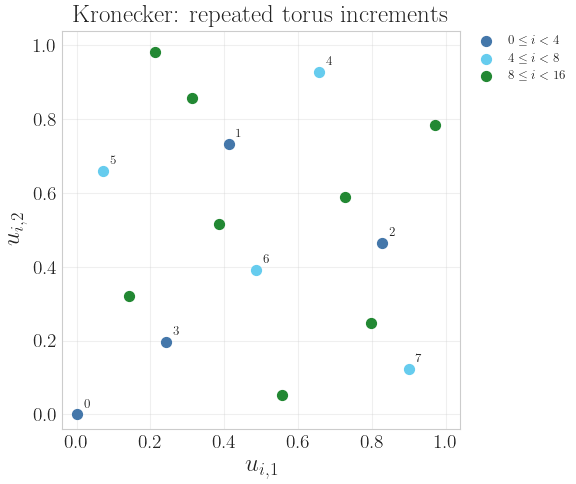

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 5.1))
for start, stop in [(0, 4), (4, 8), (8, 16)]:
    ax.scatter(*u_kronecker[start:stop].T, s=50, label=rf'${start}\le i<{stop}$')
for i, point in enumerate(u_kronecker[:8]):
    ax.annotate(str(i), point, xytext=(5, 5), textcoords='offset points', fontsize=9)
ax.set(xlim=(-.04, 1.04), ylim=(-.04, 1.04), aspect='equal',
       xlabel=r'$u_{i,1}$', ylabel=r'$u_{i,2}$', title='Kronecker: repeated torus increments')
ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1)); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()

## 3. Digital: recover generator columns at powers of two

QMCPy's `DigitalNetB2` uses Sobol' generating matrices by default. Turn randomization off and explicitly request `RADICAL INVERSE` ordering. If $i=i_0+2i_1+4i_2+\cdots$, then
\begin{align*}
\boldsymbol u_i=i_0\boldsymbol c_0\oplus i_1\boldsymbol c_1\oplus i_2\boldsymbol c_2\oplus\cdots.
\end{align*}
Here $\oplus$ is digitwise addition modulo 2, **without carries**. Since $2^k$ has just one nonzero index bit,
\begin{align*}
\boldsymbol c_k=\boldsymbol u_{2^k}.
\end{align*}
Each coordinate of $\boldsymbol c_k$ is the binary fraction represented by column $k$ of that coordinate's generating matrix. Read columns from points 1, 2, 4; predict points 3, 5, 6, 7 by XOR. A prefix of length 8 tells us nothing about the next column $\boldsymbol c_3$.

In [8]:
digital = qp.DigitalNetB2(2, randomize=False, order='RADICAL INVERSE')
u_digital = digital.gen_samples(16, warn=False)
point_table(u_digital, range(8))

bits = 3  # The first eight points here lie on the 1/8 grid.
scale = 2**bits
encoded = np.rint(scale * u_digital[:8]).astype(np.uint64)
columns = encoded[[1, 2, 4]]
for k, column in enumerate(columns):
    print(f'c_{k}:', [f'0.{int(v):0{bits}b}_2' for v in column])


def xor_reconstruct(n, columns, shift=None):
    """Combine encoded binary fractions according to the bits of the index."""
    assert n <= 2**len(columns)
    result = np.zeros((n, columns.shape[1]), dtype=np.uint64)
    for k, column in enumerate(columns):
        result ^= (((np.arange(n) >> k) & 1).astype(np.uint64)[:, None] * column)
    if shift is not None:
        result ^= shift
    return result

predicted = xor_reconstruct(8, columns) / scale
np.testing.assert_array_equal(predicted, u_digital[:8])
for j in range(2):
    matrix = np.array([[int((v >> np.uint64(bits-1-row)) & np.uint64(1))
                        for v in columns[:, j]] for row in range(bits)])
    print(f'Coordinate {j+1} generating matrix (first 3 rows and columns):\n{matrix}')
print('All eight points agree with the recovered XOR construction.')

| $i$ | $u_{i,1}$ | $u_{i,2}$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 1 | 1/2 | 1/2 |
| 2 | 1/4 | 3/4 |
| 3 | 3/4 | 1/4 |
| 4 | 1/8 | 5/8 |
| 5 | 5/8 | 1/8 |
| 6 | 3/8 | 3/8 |
| 7 | 7/8 | 7/8 |

c_0: ['0.100_2', '0.100_2']
c_1: ['0.010_2', '0.110_2']
c_2: ['0.001_2', '0.101_2']
Coordinate 1 generating matrix (first 3 rows and columns):
[[1 0 0]
 [0 1 0]
 [0 0 1]]
Coordinate 2 generating matrix (first 3 rows and columns):
[[1 1 1]
 [0 1 0]
 [0 0 1]]
All eight points agree with the recovered XOR construction.


### Same first four points, different fifth points

The lattice with $(1,3)$ and this digital sequence both begin
$\boldsymbol u_0=(0,0)$, $\boldsymbol u_1=(1/2,1/2)$,
$\boldsymbol u_2=(1/4,3/4)$, $\boldsymbol u_3=(3/4,1/4)$.

At $i=4$, the lattice gives $(1/8,3/8)$, while the digital sequence gives $(1/8,5/8)$. Their different rules become visible. A finite prefix can support or reject a proposed construction; it cannot uniquely identify a family or all later generator parameters.

Fifth point, lattice: [0.125 0.375]
Fifth point, digital: [0.125 0.625]


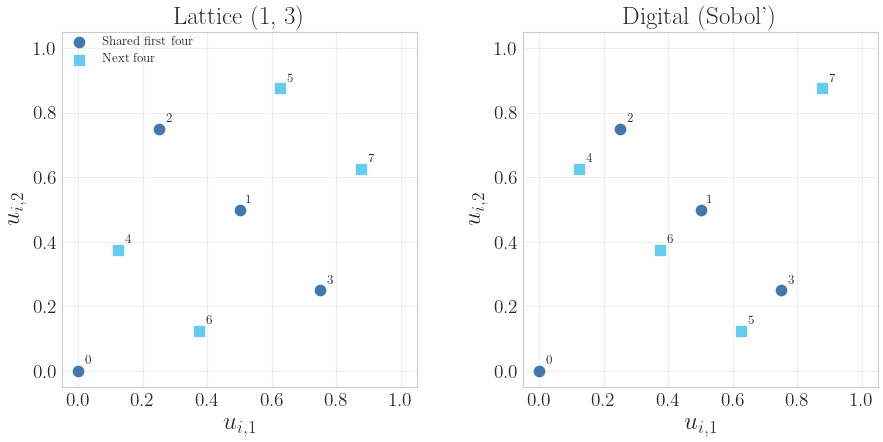

In [9]:
np.testing.assert_array_equal(u_lattice[:4], u_digital[:4])
assert not np.array_equal(u_lattice[4], u_digital[4])
print('Fifth point, lattice:', u_lattice[4])
print('Fifth point, digital:', u_digital[4])
fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.5))
for ax, points, title in zip(axes, [u_lattice, u_digital], ['Lattice (1, 3)', "Digital (Sobol')"]):
    ax.scatter(*points[:4].T, s=55, label='Shared first four')
    ax.scatter(*points[4:8].T, s=55, marker='s', label='Next four')
    for i, point in enumerate(points[:8]):
        ax.annotate(str(i), point, xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax.set(xlim=(-.05, 1.05), ylim=(-.05, 1.05), aspect='equal',
           xlabel=r'$u_{i,1}$', ylabel=r'$u_{i,2}$', title=title)
    ax.grid(alpha=.3)
axes[0].legend(fontsize=9, loc='upper left')
fig.tight_layout(); plt.show()

### Order matters when reading columns

`GRAY` ordering uses the index bits of $g(i)=i\mathbin{\mathrm{xor}}\lfloor i/2\rfloor$. The first $2^m$ points are the same set, but the rows differ. In Gray order, point $i=2$ combines columns 0 and 1; it does not isolate column 1. First establish the ordering, or undo it before reading generator columns.

In [10]:
gray = qp.DigitalNetB2(2, randomize=False, order='GRAY')
u_gray = gray.gen_samples(16, warn=False)
i = np.arange(16)
gray_indices = i ^ (i >> 1)
np.testing.assert_array_equal(u_gray, u_digital[gray_indices])
print('Gray row i -> radical-inverse row g(i):', gray_indices[:8])
point_table(u_gray, range(4))

Gray row i -> radical-inverse row g(i): [0 1 3 2 6 7 5 4]


| $i$ | $u_{i,1}$ | $u_{i,2}$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 1 | 1/2 | 1/2 |
| 2 | 3/4 | 1/4 |
| 3 | 1/4 | 3/4 |

## 4. Randomization: what structure survives?

An ordinary shift uses $\boldsymbol U_i=(\boldsymbol u_i+\boldsymbol\Delta)\pmod1$. If $\boldsymbol\Delta\sim\operatorname{Unif}([0,1)^d)$, each point is marginally uniform. The points in a run remain dependent. Subtract $\boldsymbol U_0$ modulo 1 to recover an origin-starting lattice or Kronecker prefix.

A digital shift uses $\boldsymbol U_i=\boldsymbol u_i\oplus\boldsymbol\Delta$. Recover columns by **XOR with point zero**, rather than by ordinary subtraction. The following diagnostic retains only the first 12 binary digits. It identifies the observed leading bits; it does not recover unseen digits.

In [11]:
shifted_lattice = qp.Lattice(2, generating_vector=zeta, m_max=10,
                             randomize='SHIFT', order='RADICAL INVERSE', seed=2026)
U_lattice = shifted_lattice.gen_samples(8)
np.testing.assert_allclose((U_lattice - U_lattice[0]) % 1, u_lattice[:8], atol=1e-14)

shift = qp.IIDStdUniform(2, seed=2027).gen_samples(1)[0]
U_kronecker = kronecker(16, kronecker_zeta, shift)
np.testing.assert_allclose(np.diff(U_kronecker, axis=0) % 1,
                           np.tile(kronecker_zeta, (15, 1)), atol=1e-14)

shifted_digital = qp.DigitalNetB2(2, randomize='DS', order='RADICAL INVERSE', seed=2028)
U_digital = shifted_digital.gen_samples(8)
leading_bits = 12
scale_shift = 2**leading_bits
encoded_shifted = np.floor(U_digital * scale_shift).astype(np.uint64)
encoded_origin = encoded_shifted[0]
recovered_columns = encoded_shifted[[1, 2, 4]] ^ encoded_origin
np.testing.assert_array_equal(xor_reconstruct(8, recovered_columns, encoded_origin), encoded_shifted)
np.testing.assert_array_equal(recovered_columns,
    np.floor(u_digital[[1, 2, 4]] * scale_shift).astype(np.uint64))
print('Ordinary-shift recovery and 12-bit digital-shift recovery both pass.')
point_table(U_digital, range(4), fractions=False)

Ordinary-shift recovery and 12-bit digital-shift recovery both pass.


| $i$ | $u_{i,1}$ | $u_{i,2}$ |
|---:|---:|---:|
| 0 | 0.483038 | 0.993991 |
| 1 | 0.983038 | 0.493991 |
| 2 | 0.233038 | 0.243991 |
| 3 | 0.733038 | 0.743991 |

QMCPy's default digital randomization, `LMS DS`, combines a linear matrix scramble with a digital shift. It retains a linear digital construction, with changed columns. Nested uniform scrambling (`NUS`) is more general and need not satisfy these linear XOR identities. Neither digital shift nor scrambling is ordinary addition modulo 1.

Use `plot_proj` to inspect projections and the nested blocks. The following plot uses the default scrambled Sobol' generator in three dimensions; a good-looking $(1,2)$ projection alone cannot establish quality in other coordinates.

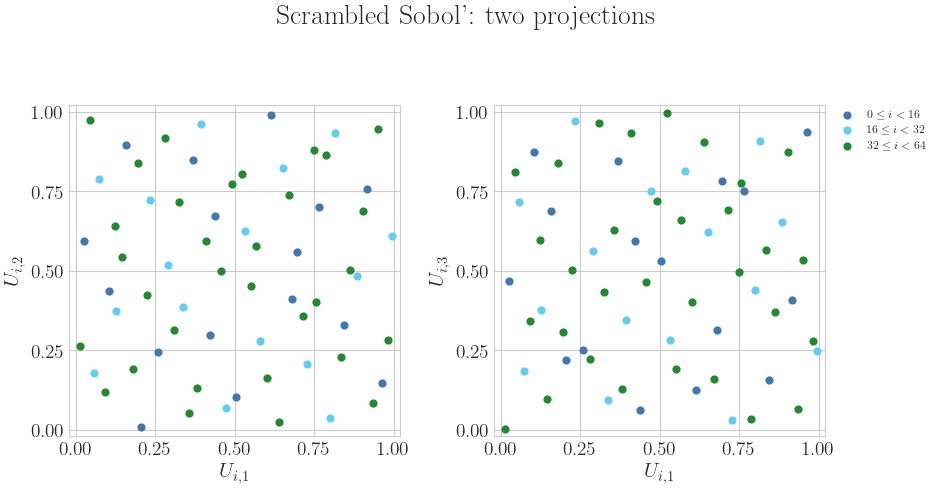

In [12]:
scrambled = qp.DigitalNetB2(3, randomize='LMS DS', seed=2029)
fig, axes = qp.plot_proj(scrambled, n=[16, 32, 64], d_horizontal=[1],
                          d_vertical=[2, 3], marker_size=24, figfac=4.3,
                          axis_pad=.02, font_family='serif',
                          fig_title="Scrambled Sobol': two projections")
fig.set_size_inches(9.6, 4.9)
for ax, j in zip(axes[0], [2, 3]):
    ax.set_xlabel(r'$U_{i,1}$'); ax.set_ylabel(rf'$U_{{i,{j}}}$')
axes[0, 1].legend([r'$0\le i<16$', r'$16\le i<32$', r'$32\le i<64$'],
                  fontsize=8, loc='upper left', bbox_to_anchor=(1.02, 1))
fig.tight_layout(); plt.show()

## 5. One integrand, four sampling methods

Keep the two-dimensional Keister integrand fixed and change only the cube-point construction:
\begin{align*}
\boldsymbol X&=\boldsymbol T(\boldsymbol U)
=\Phi^{-1}(\boldsymbol U)/\sqrt2,\qquad
\boldsymbol X\sim\operatorname{Norm}(\boldsymbol0,\mathsf I_2/2),\\
Y&=f(\boldsymbol X)=\pi\cos(\|\boldsymbol X\|),\\
h(\boldsymbol u)&=f(\boldsymbol T(\boldsymbol u)),\qquad
\mu=\int_{[0,1]^2}h(\boldsymbol u)\,\mathrm d\boldsymbol u.
\end{align*}
QMCPy's `Keister` supplies this transformation and integrand. Its exact-integral routine supplies the benchmark. Compare IID, randomly shifted lattice (QMCPy's built-in generator), randomly shifted irrational Kronecker, and scrambled Sobol'. We do not use the small lattice $(1,3)$ as a production generator.

Use **32 independent runs** at each sample size. Within each run, keep nested prefixes as $n$ grows; errors at different $n$ are therefore correlated. The plotted empirical RMSE estimates single-run error, not the error of the average of 32 runs. It is an experiment on this integrand, not a guaranteed rate or a universal ranking.

Keister benchmark: 1.808186429264


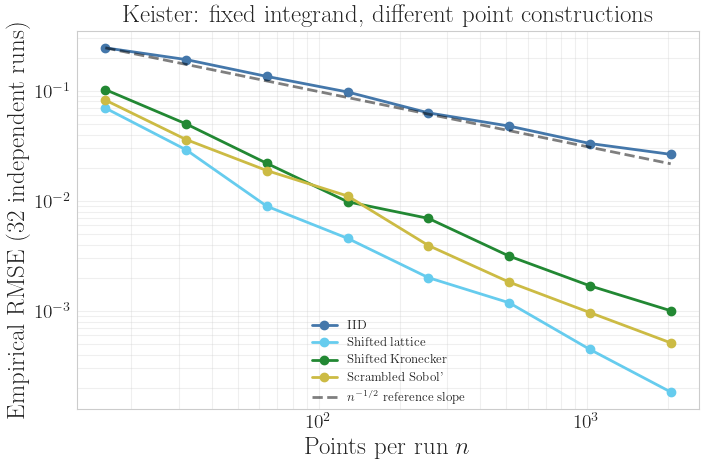

| Method | RMSE at $n=2048$ | Across-run SD | SE of the 32-run mean |
|---|---:|---:|---:|
| IID | 0.0265 | 0.0269 | 0.00475 |
| Shifted lattice | 0.000183 | 0.000186 | 3.28e-05 |
| Shifted Kronecker | 0.001 | 0.00102 | 0.00018 |
| Scrambled Sobol' | 0.000513 | 0.000521 | 9.2e-05 |

In [13]:
dimension = 2
replications = 32
sample_sizes = 2**np.arange(4, 12)
n_max = int(sample_sizes[-1])
keister = qp.Keister(qp.IIDStdUniform(dimension, seed=2030))
reference = keister.exact_integ(dimension)
print(f'Keister benchmark: {reference:.12f}')

seed_sequences = np.random.SeedSequence(5652026).spawn(4 * replications)
estimates = {name: np.empty((replications, len(sample_sizes)))
             for name in ['IID', 'Shifted lattice', 'Shifted Kronecker', "Scrambled Sobol'"]}
for method_index, (name, values) in enumerate(estimates.items()):
    for r in range(replications):
        seed = seed_sequences[method_index * replications + r]
        if name == 'IID':
            U = qp.IIDStdUniform(dimension, seed=seed).gen_samples(n_max)
        elif name == 'Shifted lattice':
            U = qp.Lattice(dimension, randomize='SHIFT', seed=seed).gen_samples(n_max)
        elif name == 'Shifted Kronecker':
            shift = qp.IIDStdUniform(dimension, seed=seed).gen_samples(1)[0]
            U = kronecker(n_max, kronecker_zeta, shift)
        else:
            U = qp.DigitalNetB2(dimension, randomize='LMS DS', seed=seed).gen_samples(n_max)
        assert U.shape == (n_max, dimension)
        assert np.all((U > 0) & (U < 1))  # Quantile inputs avoid cube endpoints.
        Y = keister.f(U)
        assert np.all(np.isfinite(Y))
        cumulative_sums = np.cumsum(Y)
        values[r] = cumulative_sums[sample_sizes-1] / sample_sizes

rmse = {name: np.sqrt(np.mean((values-reference)**2, axis=0))
        for name, values in estimates.items()}
fig, ax = plt.subplots(figsize=(7.3, 4.9))
for name, errors in rmse.items():
    ax.loglog(sample_sizes, errors, 'o-', label=name)
ax.loglog(sample_sizes, rmse['IID'][0]*(sample_sizes/sample_sizes[0])**(-.5),
          'k--', alpha=.5, label=r'$n^{-1/2}$ reference slope')
ax.set(xlabel=r'Points per run $n$', ylabel='Empirical RMSE (32 independent runs)',
       title='Keister: fixed integrand, different point constructions')
ax.grid(which='both', alpha=.3); ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

lines = ['| Method | RMSE at $n=2048$ | Across-run SD | SE of the 32-run mean |',
         '|---|---:|---:|---:|']
for name, values in estimates.items():
    run_sd = values[:, -1].std(ddof=1)
    lines.append(f'| {name} | {rmse[name][-1]:.3g} | {run_sd:.3g} | {run_sd/np.sqrt(replications):.3g} |')
display(Markdown('\n'.join(lines)))

Randomization makes these single-run estimators unbiased in ideal arithmetic because every $\boldsymbol U_i$ has the uniform marginal distribution. The empirical RMSE still has sampling uncertainty; increasing the number of independent runs gives a more precise comparison. Lattice and Kronecker shifts preserve their torus geometry; digital scrambling changes columns while preserving digital structure. The interaction with $h$ determines the integration error.

For error assessment, use the variation **between independent runs**, not the IID standard-error formula applied to dependent outputs within one run. Across-run SD measures single-run variability; dividing it by $\sqrt{32}$ measures the standard error of the 32-run average.

Adaptive stopping is developed separately in [Keister Example](../applications/KeisterExample.ipynb) and [Asian Option Variance Reduction](../performance/AsianOptionVarianceReduction.ipynb). Their replication intervals and conditional Walsh-decay bounds have different assumptions. This notebook keeps the sample sizes fixed and does not duplicate those stopping implementations.

## 6. Try recovering a hidden construction

Before running the next cell, predict what you would look for:

1. In an unshifted radical-inverse lattice prefix of length 16, which row identifies the generating vector modulo 16?
2. In a shifted Kronecker prefix, which differences identify the increment?
3. In a digitally shifted prefix of length 8, which three rows, together with row zero, identify the first three columns?
4. Could any of these prefixes uniquely identify an infinite sequence? What additional row would distinguish $(1,5)$ from $(1,21)$?

In [14]:
hidden_lattice = qp.Lattice(2, generating_vector=np.array([1, 5], dtype=np.uint64),
                            m_max=10, randomize=False, order='RADICAL INVERSE')
hidden_points = hidden_lattice.gen_samples(16, warn=False)
point_table(hidden_points)
# Recover from the observed prefix, then verify rows not used for recovery.
answer = np.rint(16 * hidden_points[8]).astype(np.uint64)
np.testing.assert_array_equal((radical_inverse_2(np.arange(16))[:, None]*answer) % 1,
                              hidden_points)
print('Recovered generator modulo 16:', answer)
print('To distinguish generators (1,5) and (1,21), inspect i=16 (the 17th point).')

| $i$ | $u_{i,1}$ | $u_{i,2}$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 1 | 1/2 | 1/2 |
| 2 | 1/4 | 1/4 |
| 3 | 3/4 | 3/4 |
| 4 | 1/8 | 5/8 |
| 5 | 5/8 | 1/8 |
| 6 | 3/8 | 7/8 |
| 7 | 7/8 | 3/8 |
| 8 | 1/16 | 5/16 |
| 9 | 9/16 | 13/16 |
| 10 | 5/16 | 9/16 |
| 11 | 13/16 | 1/16 |
| 12 | 3/16 | 15/16 |
| 13 | 11/16 | 7/16 |
| 14 | 7/16 | 3/16 |
| 15 | 15/16 | 11/16 |

Recovered generator modulo 16: [1 5]
To distinguish generators (1,5) and (1,21), inspect i=16 (the 17th point).


## What the first points tell us

| Proposed construction and known ordering | Diagnostic | What remains unknown |
|---|---|---|
| Lattice, radical-inverse order, no shift | $2^m\boldsymbol u_{2^{m-1}}=\boldsymbol\zeta\pmod{2^m}$; predict other rows | Generator beyond its residues modulo $2^m$; quality at larger sizes |
| Kronecker, ordinary-index order | Constant $(\boldsymbol u_{i+1}-\boldsymbol u_i)\pmod1$ | Exact irrational values from rounded observations; long-run quality |
| Digital, ordinary binary index bits (`RADICAL INVERSE`) | Read columns at $i=1,2,4,\ldots$ and verify XOR combinations | Later columns and unseen output digits |
| Ordinary shift | Subtract point zero modulo 1 | Unshifted construction unless its start/order is known |
| Digital shift | XOR with point zero at the chosen digit precision | Unseen shift bits and columns |

Ordering, randomization, and precision are part of the evidence. Matching a few rows verifies a finite prediction; it does not prove a unique construction or a low discrepancy bound.

QMCPy references: [automatic projection plots](https://qmcsoftware.org/QMCSoftware/demos/plot_proj_function/), [lattice source and API](https://github.com/QMCSoftware/QMCSoftware/blob/0f6d3c28f5fdd7effb1c883bc5d0351d50987427/qmcpy/discrete_distribution/lattice/lattice.py), and [base-two digital-net source and API](https://github.com/QMCSoftware/QMCSoftware/blob/0f6d3c28f5fdd7effb1c883bc5d0351d50987427/qmcpy/discrete_distribution/digital_net_b2/digital_net_b2.py).

In [15]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 4.9 sec.
